# 🧬 Chromosome Classification — CIR-Net (InceptionResNetV2) + ResNet50
**Run after MobileNetV2 notebook. Uses same BioImLAB dataset.**

In [14]:
# Cell 1 — Setup
import os
from google.colab import files

uploaded = files.upload()
uploaded_name = list(uploaded.keys())[0]
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'wb') as f:
    f.write(uploaded[uploaded_name])
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle tensorflow scikit-learn matplotlib seaborn

if not os.path.exists('/content/bioimlab/Class_1'):
    !kaggle datasets download \
        -d arifmpthesis/bioimlab-chromosome-data-set-for-classification \
        --path /content/bioimlab --unzip -q
    print('✅ Dataset downloaded')
else:
    print('✅ Dataset already exists')


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/arifmpthesis/bioimlab-chromosome-data-set-for-classification
License(s): other
✅ Dataset downloaded


In [ ]:
# Cell 2 — Imports + Config
import os, re, random, warnings, time, json
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.applications import InceptionResNetV2, ResNet50
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              precision_score, recall_score,
                              confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    [tf.config.experimental.set_memory_growth(g, True) for g in gpus]
    print(f'✅ GPU: {gpus[0].name}')
else:
    print('⚠️ No GPU — use Runtime → Change runtime type → T4 GPU')

tf.keras.mixed_precision.set_global_policy('float32')

# Config
IMG_SIZE       = 224    # full size for both models
BATCH_SIZE     = 64
NUM_CLASSES    = 24
EPOCHS_P1      = 10
EPOCHS_P2      = 20
LR_P1          = 1e-3       # safer starting LR for Phase 1
DROPOUT        = 0.40       # more dropout to fight overfitting
L2_REG         = 1e-4       # L2 weight regularization for dense head
LABEL_SMOOTH   = 0.05       # lower smoothing
REPEAT_FACTOR  = 1
CONF_THRESHOLD = 0.65
PATIENCE       = 15

CLASS_NAMES = [str(i) for i in range(1, 23)] + ['X', 'Y']
AUTOTUNE    = tf.data.AUTOTUNE
OUTPUT_DIR  = '/content'
SAVE_DIR    = '/content/drive/MyDrive/chromosome_models'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('✅ Config ready')
print(f'   IMG_SIZE   : {IMG_SIZE}')
print(f'   BATCH_SIZE : {BATCH_SIZE}')


✅ GPU: /physical_device:GPU:0
✅ Config ready
   IMG_SIZE   : 224
   BATCH_SIZE : 64


In [ ]:
# Cell 3 — Load BioImLAB dataset (handles Class_X and Class_Y correctly)
BIOIMLAB_DIR = '/content/bioimlab'

# Reset to full 24 classes at the top
NUM_CLASSES = 24
CLASS_NAMES = [str(i) for i in range(1, 23)] + ['X', 'Y']

all_records   = []
found_classes = set()

for cls_folder in sorted(os.listdir(BIOIMLAB_DIR)):
    cls_path = os.path.join(BIOIMLAB_DIR, cls_folder)
    if not os.path.isdir(cls_path):
        continue

    suffix = cls_folder.split('_')[-1].upper()
    if suffix == 'X':
        lbl = 22
    elif suffix == 'Y':
        lbl = 23
    else:
        try:
            lbl = int(suffix) - 1
        except:
            continue

    if not (0 <= lbl < 24):
        continue

    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    for fname in imgs:
        all_records.append((os.path.join(cls_path, fname), lbl))
    found_classes.add(lbl)

dist = Counter(r[1] for r in all_records)
print(f'✅ Raw total    : {len(all_records)} images')
print(f'   Classes found: {len(found_classes)}/24')
print(f'   Missing labels: {set(range(24)) - found_classes}')
print(f'   Min per class: {min(dist.values())} | Max: {max(dist.values())}')
for i in range(24):
    print(f'   Chr {CLASS_NAMES[i]:>2}: {dist.get(i, 0)}')

# ── Balance: cap at 200, oversample small classes to 150 minimum ──────────────
MAX_PER_CLASS = 200
MIN_TARGET    = 150

random.shuffle(all_records)
balanced = []
count    = defaultdict(int)

for fp, lbl in all_records:
    if count[lbl] < MAX_PER_CLASS:
        balanced.append((fp, lbl))
        count[lbl] += 1

# Oversample any class below MIN_TARGET
for cls_idx in range(24):
    cls_recs = [(fp, lbl) for fp, lbl in balanced if lbl == cls_idx]
    if len(cls_recs) == 0:
        print(f'⚠ Chr {CLASS_NAMES[cls_idx]} has 0 images — skipping')
        continue
    while count[cls_idx] < MIN_TARGET:
        balanced.append(random.choice(cls_recs))
        count[cls_idx] += 1

# ── Final counts ──────────────────────────────────────────────────────────────
dist2 = Counter(r[1] for r in balanced)
print(f'\nAfter balancing:')
print(f'   Total  : {len(balanced)} images | Classes: {len(dist2)}/24')
for i in range(24):
    print(f'   Chr {CLASS_NAMES[i]:>2}: {dist2.get(i, 0)}')

all_records = balanced

# ── CDA: Chromosome Data Augmentation (from Lin et al. 2022 paper) ────────────
# Rotates each TRAINING image at 15° steps from 15° to 345° = 23 copies per image
# This is the exact method from the paper that pushed accuracy to 95.98%
# Val and test are NOT augmented — only training set

import cv2

CDA_DIR = '/content/cda_images'
os.makedirs(CDA_DIR, exist_ok=True)

def apply_cda_to_records(records, angles=range(15, 360, 15)):
    augmented = list(records)  # keep originals
    print(f'Applying CDA to {len(records)} images × {len(list(angles))} angles...')

    for idx, (fp, lbl) in enumerate(records):
        img = cv2.imread(fp)
        if img is None:
            continue
        h, w = img.shape[:2]
        cx, cy = w // 2, h // 2

        for angle in angles:
            M       = cv2.getRotationMatrix2D((cx, cy), float(angle), 1.0)
            rotated = cv2.warpAffine(img, M, (w, h),
                                     flags=cv2.INTER_LINEAR,
                                     borderMode=cv2.BORDER_REFLECT_101)
            out_fp  = f'{CDA_DIR}/lbl{lbl}_idx{idx}_a{angle}.jpg'
            cv2.imwrite(out_fp, rotated)
            augmented.append((out_fp, lbl))

    print(f'✅ CDA done: {len(records)} → {len(augmented)} images')
    return augmented


# Split FIRST, then apply CDA only to train
fps    = [r[0] for r in all_records]
labels = [r[1] for r in all_records]

fps_tv, fps_test, lbl_tv, lbl_test = train_test_split(
    fps, labels, test_size=0.15, random_state=SEED, stratify=labels)
fps_train, fps_val, lbl_train, lbl_val = train_test_split(
    fps_tv, lbl_tv, test_size=0.176, random_state=SEED, stratify=lbl_tv)

# Apply CDA to training only
train_records_orig = list(zip(fps_train, lbl_train))
train_records      = apply_cda_to_records(train_records_orig)
random.shuffle(train_records)

val_records  = list(zip(fps_val,   lbl_val))
test_records = list(zip(fps_test,  lbl_test))

cls_wts = compute_class_weight('balanced',
                                classes=np.arange(24),
                                y=lbl_train)
class_weight_dict = dict(enumerate(cls_wts))

steps = len(train_records) // BATCH_SIZE

print(f'\n   Train (after CDA): {len(train_records)}')
print(f'   Val              : {len(val_records)}')
print(f'   Test             : {len(test_records)}')
print(f'   Steps/epoch      : {steps}')
# ── 70 / 15 / 15 stratified split ────────────────────────────────────────────
fps    = [r[0] for r in all_records]
labels = [r[1] for r in all_records]

fps_tv, fps_test, lbl_tv, lbl_test = train_test_split(
    fps, labels, test_size=0.15, random_state=SEED, stratify=labels)
fps_train, fps_val, lbl_train, lbl_val = train_test_split(
    fps_tv, lbl_tv, test_size=0.176, random_state=SEED, stratify=lbl_tv)

train_records = list(zip(fps_train, lbl_train))
val_records   = list(zip(fps_val,   lbl_val))
test_records  = list(zip(fps_test,  lbl_test))

cls_wts = compute_class_weight('balanced',
                                classes=np.arange(24),
                                y=lbl_train)
class_weight_dict = dict(enumerate(cls_wts))

steps = (len(train_records) * REPEAT_FACTOR) // BATCH_SIZE

print(f'\n   Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}')
print(f'   Steps/epoch : {steps}')
print(f'   NUM_CLASSES : {NUM_CLASSES}')

✅ Raw total    : 5474 images
   Classes found: 24/24
   Missing labels: set()
   Min per class: 45 | Max: 238
   Chr  1: 238
   Chr  2: 238
   Chr  3: 238
   Chr  4: 238
   Chr  5: 238
   Chr  6: 238
   Chr  7: 238
   Chr  8: 238
   Chr  9: 238
   Chr 10: 238
   Chr 11: 238
   Chr 12: 238
   Chr 13: 238
   Chr 14: 238
   Chr 15: 238
   Chr 16: 238
   Chr 17: 238
   Chr 18: 238
   Chr 19: 238
   Chr 20: 238
   Chr 21: 238
   Chr 22: 238
   Chr  X: 193
   Chr  Y: 45

After balancing:
   Total  : 4743 images | Classes: 24/24
   Chr  1: 200
   Chr  2: 200
   Chr  3: 200
   Chr  4: 200
   Chr  5: 200
   Chr  6: 200
   Chr  7: 200
   Chr  8: 200
   Chr  9: 200
   Chr 10: 200
   Chr 11: 200
   Chr 12: 200
   Chr 13: 200
   Chr 14: 200
   Chr 15: 200
   Chr 16: 200
   Chr 17: 200
   Chr 18: 200
   Chr 19: 200
   Chr 20: 200
   Chr 21: 200
   Chr 22: 200
   Chr  X: 193
   Chr  Y: 150
Applying CDA to 3321 images × 23 angles...
✅ CDA done: 3321 → 79704 images

   Train (after CDA): 79704
   Val  

In [ ]:
# Cell 4 — tf.data Pipeline (model-specific preprocessing)
from tensorflow.keras.applications.inception_resnet_v2 import (
    preprocess_input as cirnet_preprocess)
from tensorflow.keras.applications.resnet50 import (
    preprocess_input as resnet_preprocess)

AUTOTUNE = tf.data.AUTOTUNE

def make_preprocess_fn(preprocess_fn):
    """Returns a tf.data-compatible preprocessing function for a given model."""
    def preprocess_tf(filepath, label):
        raw = tf.io.read_file(filepath)
        img = tf.io.decode_image(raw, channels=3, expand_animations=False)
        img = tf.cast(img, tf.float32)
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = preprocess_fn(img)   # model-specific: NOT generic [-1,1]
        return img, tf.one_hot(label, NUM_CLASSES)
    return preprocess_tf

def augment_fn(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    k     = tf.random.uniform([], 0, 4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    image = tf.image.random_brightness(image, max_delta=0.05)
    return image, label

def make_dataset(records, preprocess_fn, training=True):
    fps  = [r[0] for r in records]
    lbls = [r[1] for r in records]
    ds   = tf.data.Dataset.from_tensor_slices((fps, lbls))
    if training:
        ds = ds.shuffle(len(records), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(make_preprocess_fn(preprocess_fn), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    if training:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

# Build separate datasets for each model
cirnet_train_ds = make_dataset(train_records, cirnet_preprocess, training=True)
cirnet_val_ds   = make_dataset(val_records,   cirnet_preprocess, training=False)
cirnet_test_ds  = make_dataset(test_records,  cirnet_preprocess, training=False)

resnet_train_ds = make_dataset(train_records, resnet_preprocess, training=True)
resnet_val_ds   = make_dataset(val_records,   resnet_preprocess, training=False)
resnet_test_ds  = make_dataset(test_records,  resnet_preprocess, training=False)

# Verify
for imgs, _ in cirnet_train_ds.take(1):
    print(f'✅ CIRNet  pipeline | shape: {imgs.shape} | range: [{imgs.numpy().min():.1f}, {imgs.numpy().max():.1f}]')
for imgs, _ in resnet_train_ds.take(1):
    print(f'✅ ResNet50 pipeline | shape: {imgs.shape} | range: [{imgs.numpy().min():.1f}, {imgs.numpy().max():.1f}]')

✅ CIRNet  pipeline | shape: (64, 224, 224, 3) | range: [-1.0, 0.9]
✅ ResNet50 pipeline | shape: (64, 224, 224, 3) | range: [-123.7, 134.3]


In [ ]:
# Cell 5 — Model Builder
def build_head(backbone_out, name_prefix):
    x = layers.GlobalAveragePooling2D(name=f'{name_prefix}_gap')(backbone_out)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = layers.Dropout(DROPOUT, name=f'{name_prefix}_drop1')(x)
    x = layers.Dense(
        512, use_bias=False,
        kernel_initializer='he_uniform',
        kernel_regularizer=regularizers.l2(L2_REG),
        name=f'{name_prefix}_fc1'
    )(x)
    x = layers.BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(DROPOUT * 0.75, name=f'{name_prefix}_drop2')(x)
    out = layers.Dense(
        NUM_CLASSES, activation='softmax',
        kernel_initializer='glorot_uniform',
        dtype='float32', name=f'{name_prefix}_output'
    )(x)
    return out

def build_cirnet():
    """CIR-Net: InceptionResNetV2 — paper's model (55M params)"""
    inp  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = InceptionResNetV2(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x   = base(inp, training=False)
    out = build_head(x, name_prefix='cir_')
    return Model(inp, out, name='CIRNet'), base, 50

def build_resnet50():
    """ResNet50 — strong baseline (25M params)"""
    inp  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    base = ResNet50(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    x   = base(inp, training=False)
    out = build_head(x, name_prefix='res_')
    return Model(inp, out, name='ResNet50'), base, 40

# Test builds
# Build both models and keep them
cirnet_model, cirnet_backbone, cirnet_unfreeze_n = build_cirnet()
resnet_model, resnet_backbone, resnet_unfreeze_n = build_resnet50()

for name, m in [('CIRNet', cirnet_model), ('ResNet50', resnet_model)]:
    total   = sum(v.numpy().size for v in m.weights)/1e6
    trainP1 = sum(v.numpy().size for v in m.trainable_weights)/1e6
    print(f'✅ {name}: {total:.1f}M total | {trainP1:.2f}M trainable (Phase 1)')


219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ CIRNet: 55.1M total | 0.80M trainable (Phase 1)
✅ ResNet50: 24.7M total | 1.07M trainable (Phase 1)


In [ ]:
# Cell 6 — Training Function (uses model-specific datasets)
def train_model(model, model_name, backbone, unfreeze_from,
                train_ds, val_ds):

    ckpt    = f'{OUTPUT_DIR}/{model_name}_best.keras'
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)

    # ── Phase 1: frozen backbone ──────────────────────────────────────────────
    print(f'\n{"="*55}')
    print(f'  {model_name} — PHASE 1 (frozen backbone)')
    print(f'{"="*55}')
    backbone.trainable = False

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_P1),
        loss=loss_fn,
        metrics=['accuracy']
    )
    cb_p1 = [
        keras.callbacks.ModelCheckpoint(
            ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-7, verbose=1),
    ]
    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_P1, callbacks=cb_p1,
        class_weight=class_weight_dict, verbose=1
    )
    p1_best = max(h1.history['val_accuracy']) * 100
    print(f'\n✅ Phase 1 best val_acc: {p1_best:.2f}%')

    # ── Phase 2: unfreeze top layers ──────────────────────────────────────────
    print(f'\n{"="*55}')
    print(f'  {model_name} — PHASE 2 (fine-tuning top layers)')
    print(f'{"="*55}')

    backbone.trainable = True
    reached  = False
    n_frozen = 0
    for layer in backbone.layers:
        if unfreeze_from in layer.name:
            reached = True
        if not reached:
            layer.trainable = False
            n_frozen += 1
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False   # always keep BN frozen

    print(f'   Frozen layers: {n_frozen}')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
        loss=loss_fn,
        metrics=['accuracy']
    )
    cb_p2 = [
        keras.callbacks.ModelCheckpoint(
            ckpt, monitor='val_accuracy',
            save_best_only=True, verbose=1),
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy', patience=15,
            restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=5, min_lr=1e-8, verbose=1),
    ]
    h2 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_P2, callbacks=cb_p2,
        class_weight=class_weight_dict, verbose=1
    )
    p2_best = max(h2.history['val_accuracy']) * 100
    print(f'\n✅ Phase 2 best val_acc: {p2_best:.2f}%')
    model.load_weights(ckpt)
    return h1, h2

In [ ]:
# Cell 7 — Train CIRNet
CIRNET_UNFREEZE = 'block8'
cirnet_h1, cirnet_h2 = train_model(
    cirnet_model, 'CIRNet', cirnet_backbone, CIRNET_UNFREEZE,
    cirnet_train_ds, cirnet_val_ds          # ← correct datasets
)
print('✅ CIRNet training complete')


  CIRNet — PHASE 1 (frozen backbone)
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.1313 - loss: 3.3404
Epoch 1: val_accuracy improved from None to 0.13239, saving model to /content/CIRNet_best.keras

Epoch 1: finished saving model to /content/CIRNet_best.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.1801 - loss: 3.0615 - val_accuracy: 0.1324 - val_loss: 2.9840 - learning_rate: 0.0010
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.2593 - loss: 2.6175
Epoch 2: val_accuracy improved from 0.13239 to 0.22113, saving model to /content/CIRNet_best.keras

Epoch 2: finished saving model to /content/CIRNet_best.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 23s 429ms/step - accuracy: 0.2644 - loss: 2.5961 - val_accuracy: 0.2211 - val_loss: 2.7004 - learning_rate: 0.0010
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.3018 - loss: 2.4103
Epoch 3: val_accuracy improved from 0.22113 to 0.31831, saving model to /content/CIRNet_best.keras

Epo

In [ ]:
# Cell 8 — Train ResNet50
RESNET_UNFREEZE = 'conv5_block1_1_conv'
resnet_h1, resnet_h2 = train_model(
    resnet_model, 'ResNet50', resnet_backbone, RESNET_UNFREEZE,
    resnet_train_ds, resnet_val_ds          # ← correct datasets
)
print('✅ ResNet50 training complete')


  ResNet50 — PHASE 1 (frozen backbone)
Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.1401 - loss: 3.3047
Epoch 1: val_accuracy improved from None to 0.20986, saving model to /content/ResNet50_best.keras

Epoch 1: finished saving model to /content/ResNet50_best.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 55s 664ms/step - accuracy: 0.1813 - loss: 3.0076 - val_accuracy: 0.2099 - val_loss: 2.6620 - learning_rate: 0.0010
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.3072 - loss: 2.4284
Epoch 2: val_accuracy improved from 0.20986 to 0.31972, saving model to /content/ResNet50_best.keras

Epoch 2: finished saving model to /content/ResNet50_best.keras
52/52 ━━━━━━━━━━━━━━━━━━━━ 55s 383ms/step - accuracy: 0.3107 - loss: 2.4041 - val_accuracy: 0.3197 - val_loss: 2.4370 - learning_rate: 0.0010
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.3584 - loss: 2.2397
Epoch 3: val_accuracy improved from 0.31972 to 0.39577, saving model to /content/ResNet50_b


  CIRNet — TEST RESULTS
  Accuracy  : 65.03%
  Precision : 0.6749
  Recall    : 0.6536
  F1 Macro  : 0.6508
  Paper ref : 95.98%

Per-class results:
   Chr  True  Predicted  Normal  Abnormal  Avg Conf%  Precision  Recall    F1 Status
 Chr 1    30         29      22         7  78.900002      0.759   0.733 0.746     ⚠️
 Chr 2    30         30      20        10  70.500000      0.633   0.633 0.633     ⚠️
 Chr 3    30         31      18        13  68.199997      0.677   0.700 0.689     ⚠️
 Chr 4    30         51      22        29  64.400002      0.451   0.767 0.568     ⚠️
 Chr 5    30         36      17        19  63.099998      0.583   0.700 0.636     ⚠️
 Chr 6    30         13       3        10  52.599998      0.615   0.267 0.372      ❌
 Chr 7    30         29       9        20  57.200001      0.655   0.633 0.644     ⚠️
 Chr 8    30         24       9        15  55.099998      0.625   0.500 0.556     ⚠️
 Chr 9    30         22       6        16  54.099998      0.636   0.467 0.538     ⚠️


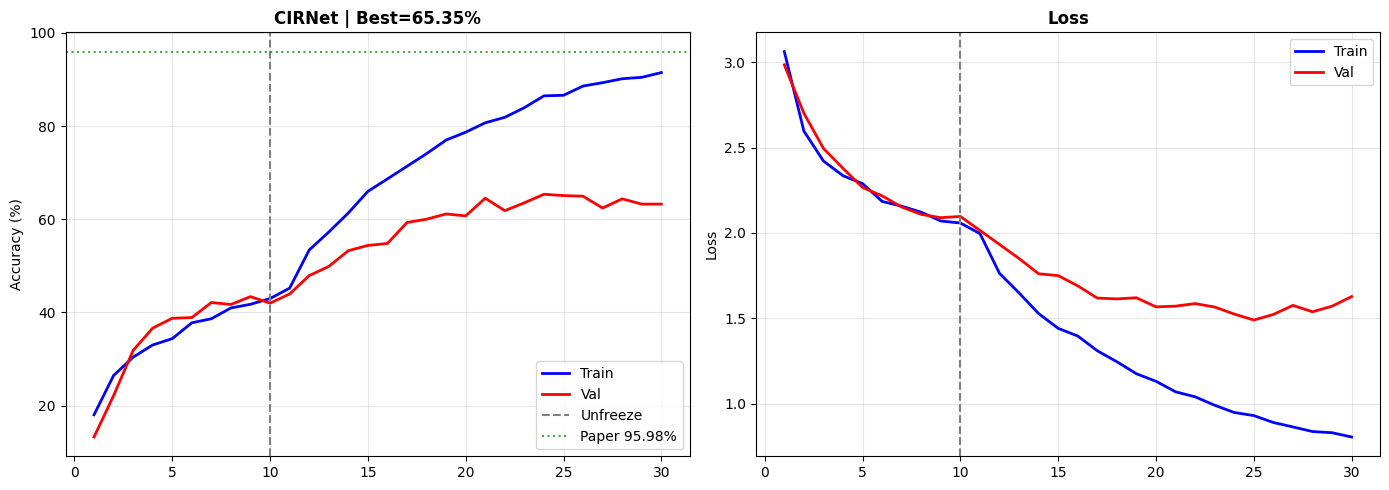

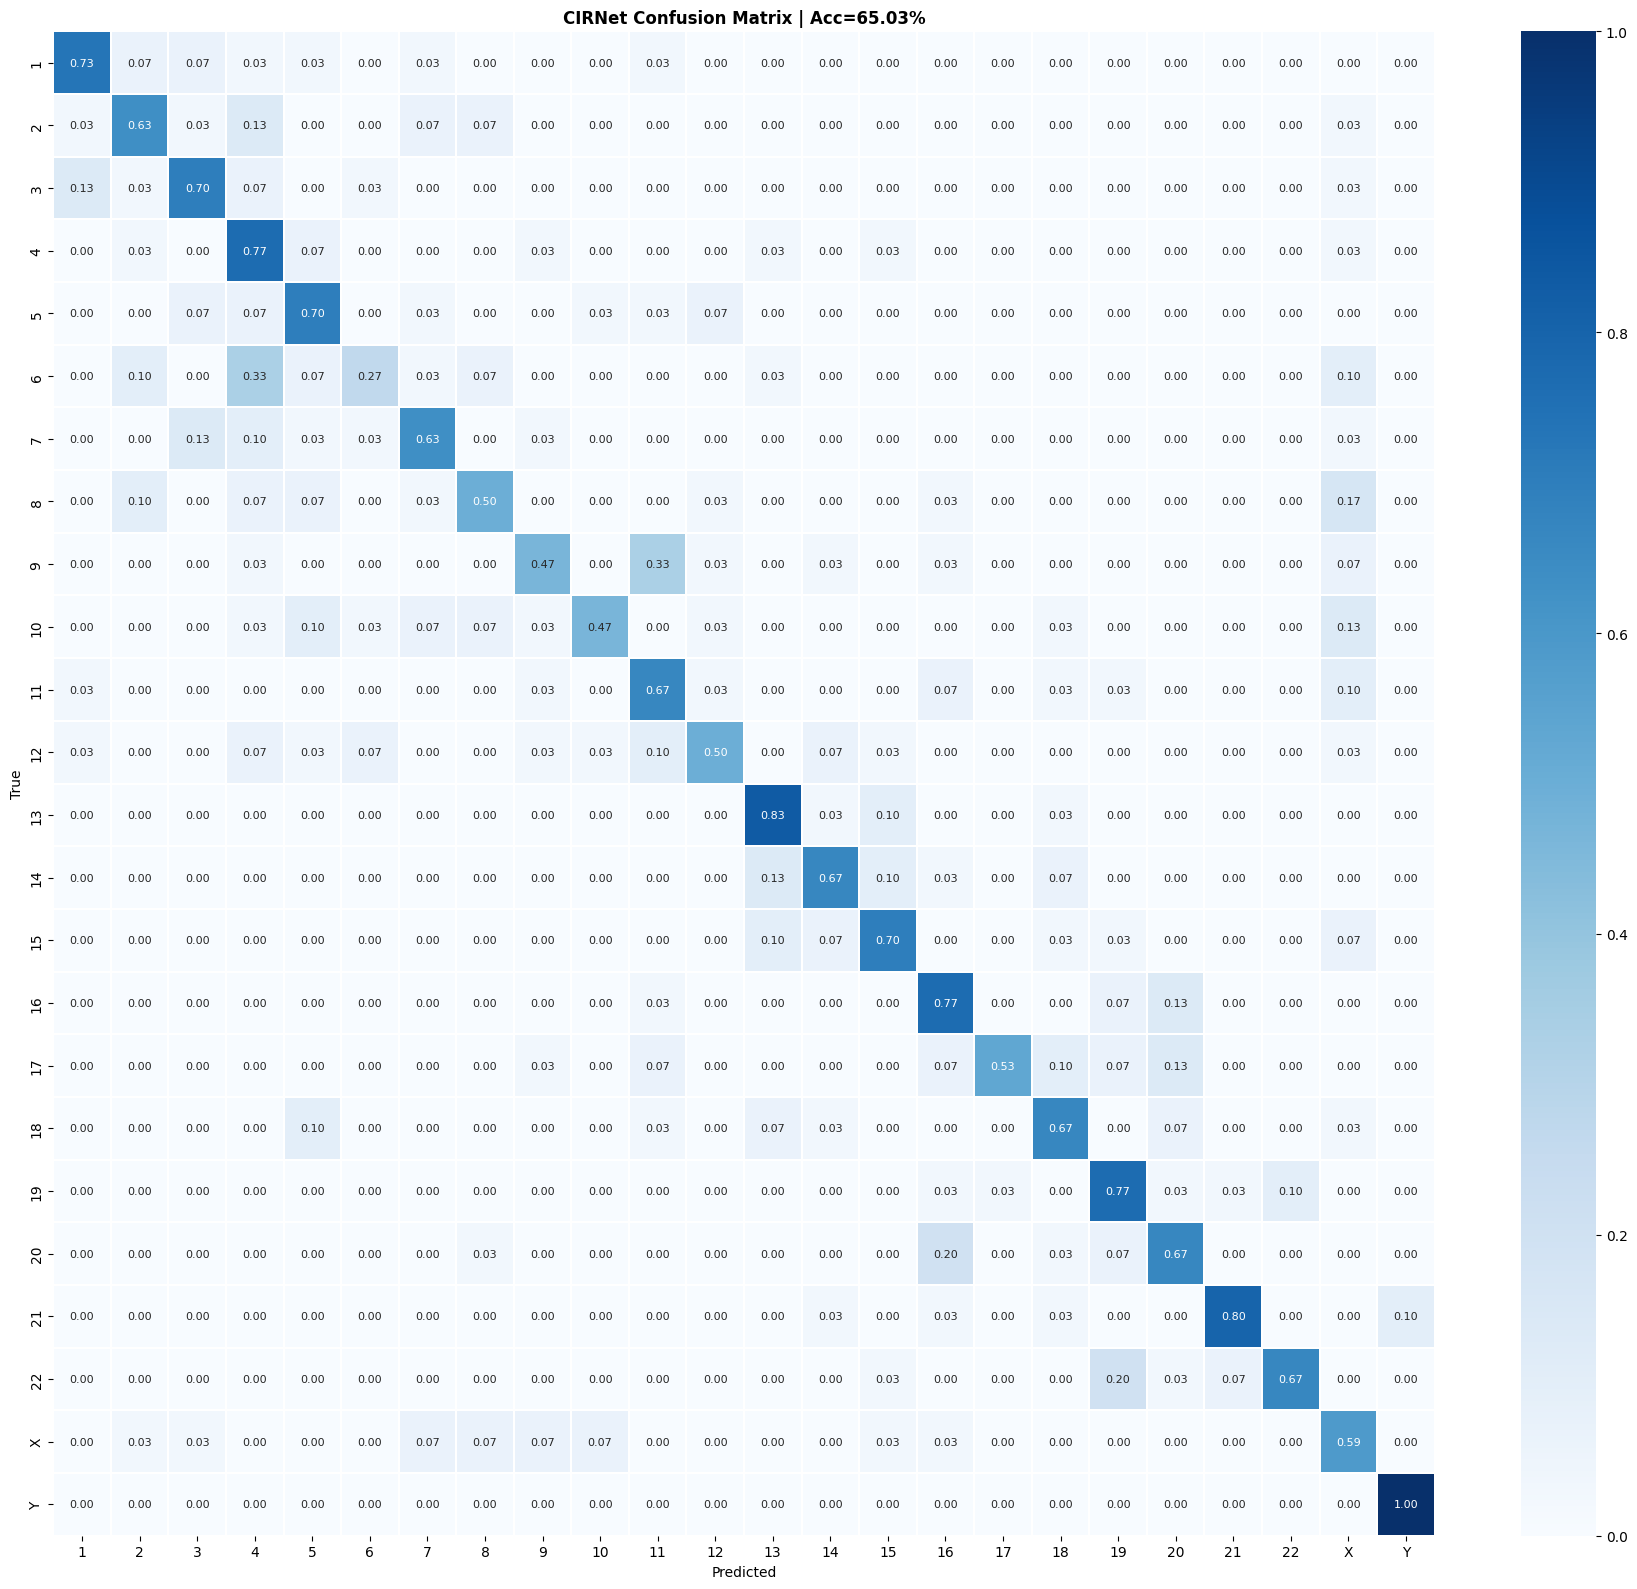

✅ Saved: CIRNet_results.csv | curves.png | confusion.png | probs.npy

  ResNet50 — TEST RESULTS
  Accuracy  : 65.17%
  Precision : 0.6753
  Recall    : 0.6550
  F1 Macro  : 0.6563
  Paper ref : 95.98%

Per-class results:
   Chr  True  Predicted  Normal  Abnormal  Avg Conf%  Precision  Recall    F1 Status
 Chr 1    30         25      18         7  76.400002      0.840   0.700 0.764     ⚠️
 Chr 2    30         21       9        12  63.000000      0.714   0.500 0.588     ⚠️
 Chr 3    30         26      20         6  78.500000      0.692   0.600 0.643     ⚠️
 Chr 4    30         41      30        11  79.099998      0.561   0.767 0.648     ⚠️
 Chr 5    30         36      19        17  68.699997      0.528   0.633 0.576     ⚠️
 Chr 6    30         49      21        28  63.200001      0.388   0.633 0.481      ❌
 Chr 7    30         38      18        20  64.400002      0.579   0.733 0.647     ⚠️
 Chr 8    30         38      11        27  57.200001      0.447   0.567 0.500     ⚠️
 Chr 9    30  

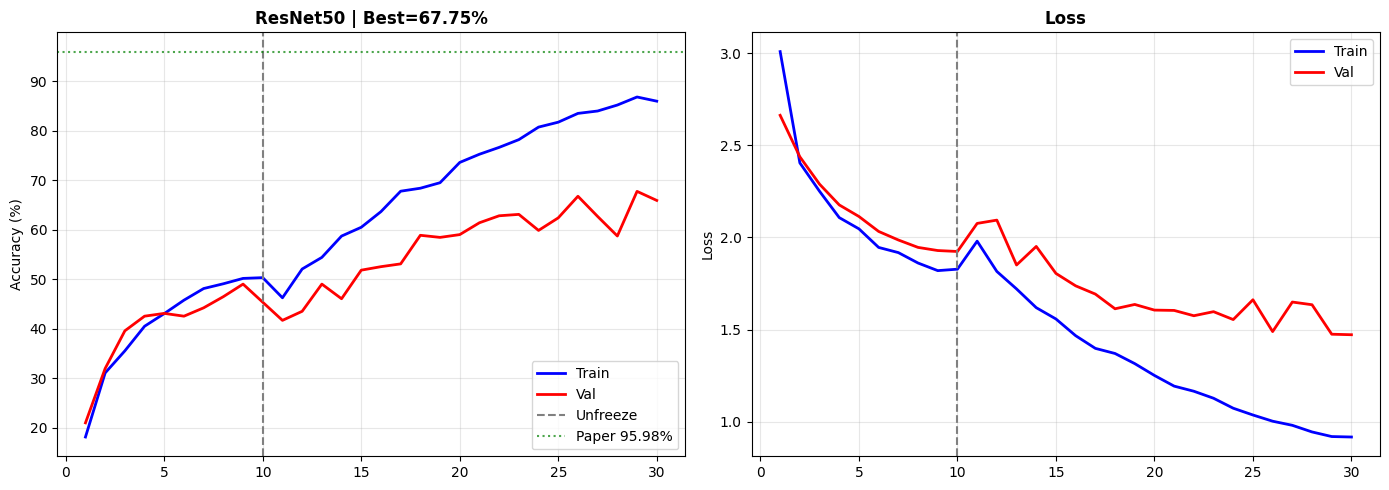

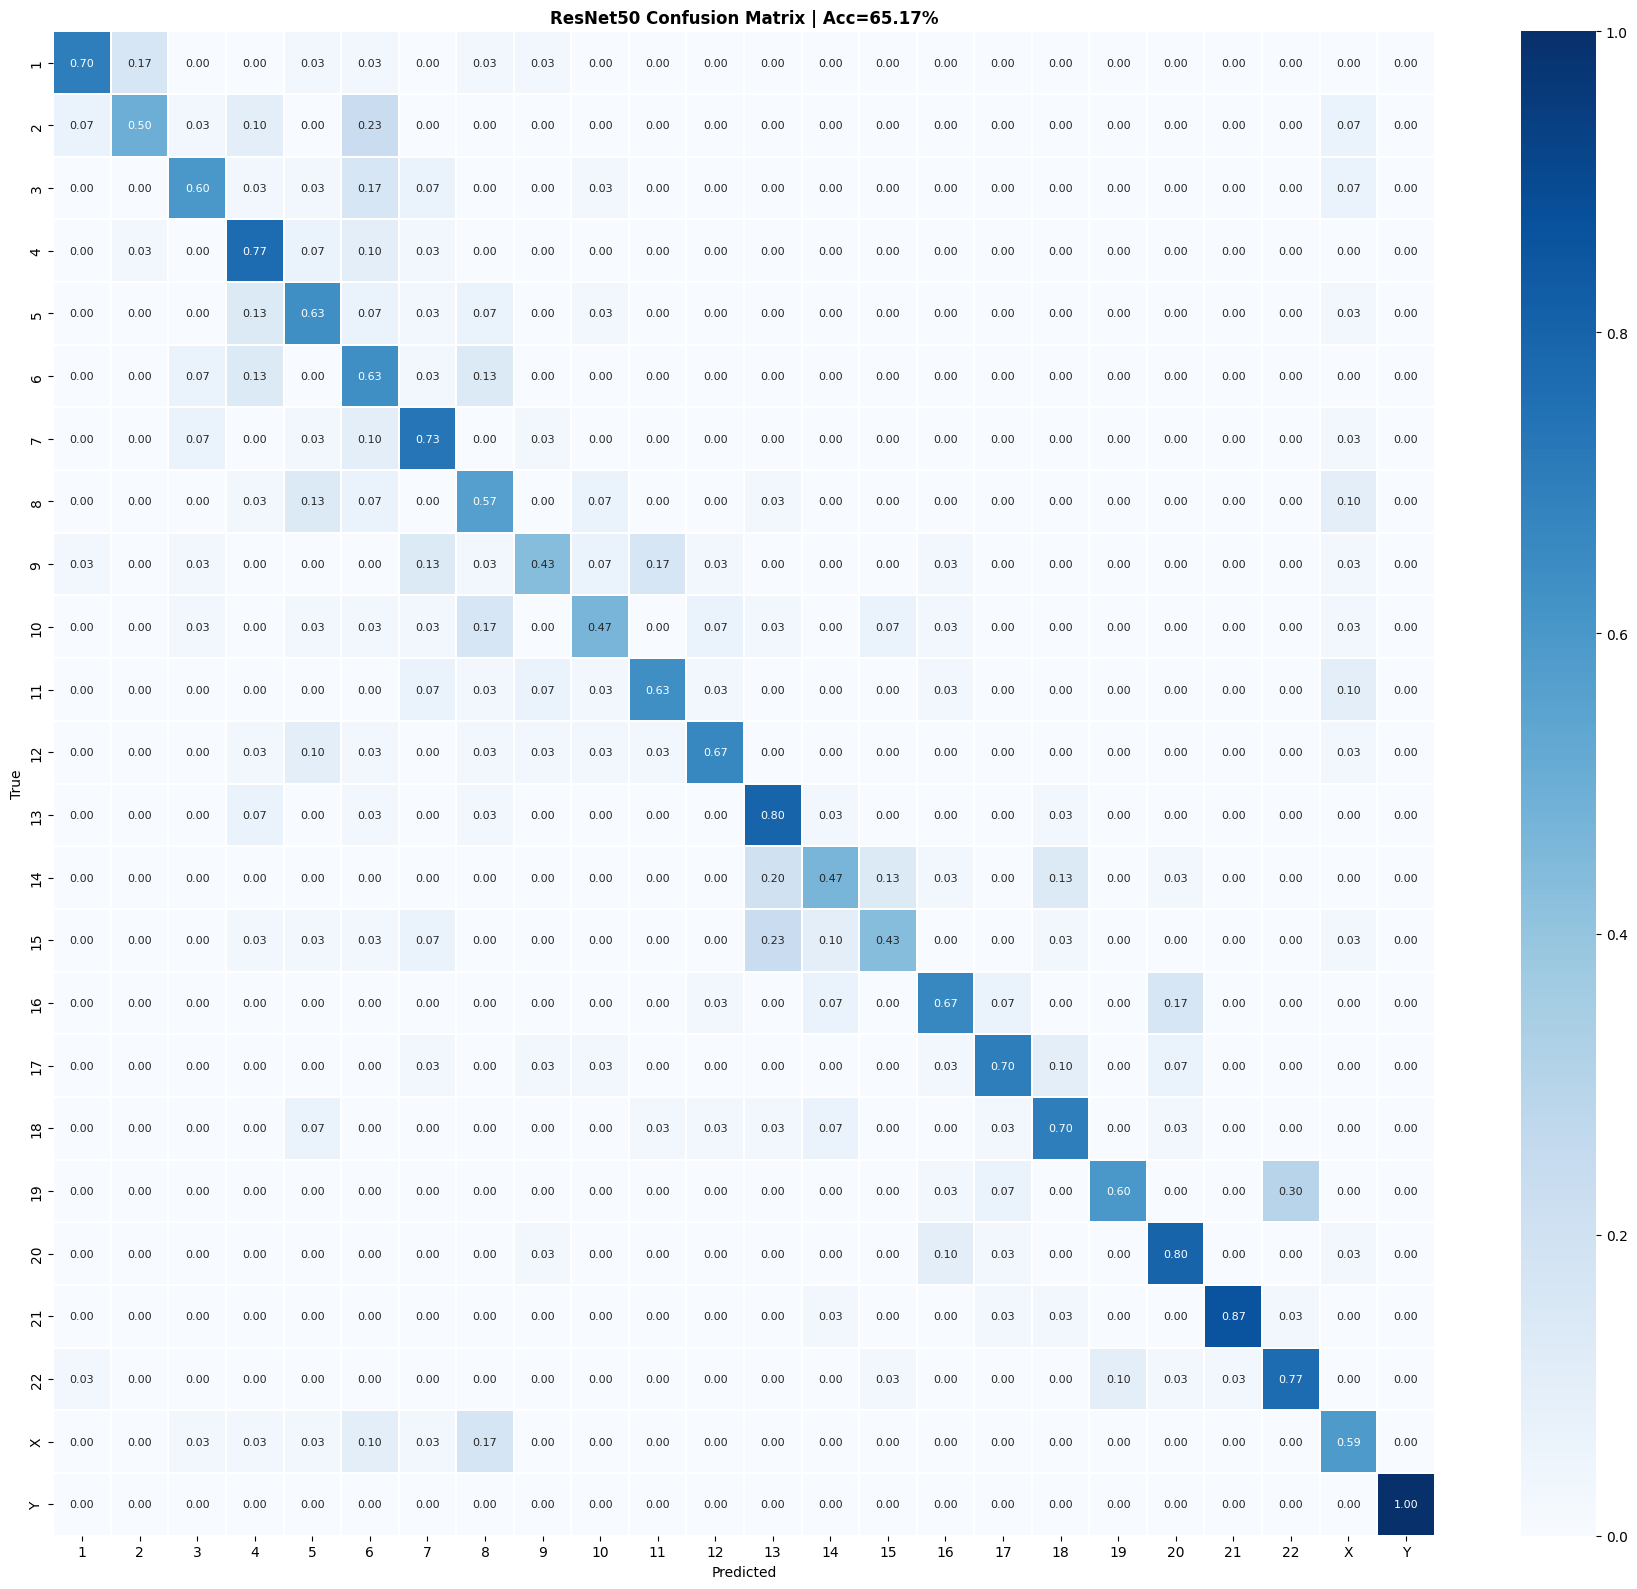

✅ Saved: ResNet50_results.csv | curves.png | confusion.png | probs.npy


In [ ]:
# Cell 9 — Evaluate both models
def evaluate(model, model_name, test_ds, h1, h2):
    probs = model.predict(test_ds, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    true  = np.array(lbl_test)

    acc  = accuracy_score(true, preds) * 100
    f1   = f1_score(true, preds, average='macro', zero_division=0)
    prec = precision_score(true, preds, average='macro', zero_division=0)
    rec  = recall_score(true, preds, average='macro', zero_division=0)

    print(f'\n{"="*55}')
    print(f'  {model_name} — TEST RESULTS')
    print(f'{"="*55}')
    print(f'  Accuracy  : {acc:.2f}%')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Macro  : {f1:.4f}')
    print(f'  Paper ref : 95.98%')
    print(f'{"="*55}')

    # Per-class table
    per_f1   = f1_score(true, preds, average=None, zero_division=0)
    per_prec = precision_score(true, preds, average=None, zero_division=0)
    per_rec  = recall_score(true, preds, average=None, zero_division=0)
    pred_c   = Counter(preds.tolist())
    true_c   = Counter(true.tolist())
    norm_c   = Counter(int(p) for p, c in zip(preds, confs) if c >= CONF_THRESHOLD)
    abn_c    = Counter(int(p) for p, c in zip(preds, confs) if c < CONF_THRESHOLD)

    rows = []
    for i in range(NUM_CLASSES):
        cs = [c for p, c in zip(preds, confs) if p == i]
        rows.append({
            'Chr'      : f'Chr {CLASS_NAMES[i]}',
            'True'     : true_c.get(i, 0),
            'Predicted': pred_c.get(i, 0),
            'Normal'   : norm_c.get(i, 0),
            'Abnormal' : abn_c.get(i, 0),
            'Avg Conf%': round(np.mean(cs) * 100, 1) if cs else 0.0,
            'Precision': round(per_prec[i], 3),
            'Recall'   : round(per_rec[i], 3),
            'F1'       : round(per_f1[i], 3),
            'Status'   : '✅' if per_f1[i] >= 0.80 else ('⚠️' if per_f1[i] >= 0.50 else '❌')
        })

    df = pd.DataFrame(rows)
    print(f'\nPer-class results:')
    print(df.to_string(index=False))
    df.to_csv(f'{OUTPUT_DIR}/{model_name}_results.csv', index=False)

    # Training curves
    acc_h     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc_h = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss_h    = h1.history['loss']         + h2.history['loss']
    val_loss_h= h1.history['val_loss']     + h2.history['val_loss']
    p1_end    = len(h1.history['accuracy'])
    ep        = range(1, len(acc_h) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(ep, [a*100 for a in acc_h],     'b-', lw=2, label='Train')
    ax1.plot(ep, [a*100 for a in val_acc_h], 'r-', lw=2, label='Val')
    ax1.axvline(p1_end, color='gray', linestyle='--', label='Unfreeze')
    ax1.axhline(95.98,  color='green', linestyle=':', alpha=0.7, label='Paper 95.98%')
    ax1.set_title(f'{model_name} | Best={max(val_acc_h)*100:.2f}%', fontweight='bold')
    ax1.set_ylabel('Accuracy (%)'); ax1.legend(); ax1.grid(alpha=0.3)
    ax2.plot(ep, loss_h,     'b-', lw=2, label='Train')
    ax2.plot(ep, val_loss_h, 'r-', lw=2, label='Val')
    ax2.axvline(p1_end, color='gray', linestyle='--')
    ax2.set_title('Loss', fontweight='bold')
    ax2.set_ylabel('Loss'); ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Confusion matrix
    cm   = confusion_matrix(true, preds)
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.3, ax=ax, vmin=0, vmax=1,
                annot_kws={'size': 8})
    ax.set_title(f'{model_name} Confusion Matrix | Acc={acc:.2f}%', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/{model_name}_confusion.png', dpi=150, bbox_inches='tight')
    plt.show()

    np.save(f'{OUTPUT_DIR}/{model_name}_test_probs.npy', probs)
    np.save(f'{OUTPUT_DIR}/lbl_test.npy', true)
    print(f'✅ Saved: {model_name}_results.csv | curves.png | confusion.png | probs.npy')
    return {'name': model_name, 'acc': acc, 'f1': f1,
            'prec': prec, 'rec': rec, 'probs': probs}


cirnet_res = evaluate(cirnet_model, 'CIRNet',   cirnet_test_ds, cirnet_h1, cirnet_h2)
resnet_res = evaluate(resnet_model, 'ResNet50', resnet_test_ds, resnet_h1, resnet_h2)


  FINAL MODEL COMPARISON
                     Model Accuracy Precision Recall     F1
CIRNet (InceptionResNetV2)   65.03%    0.6749 0.6536 0.6508
                  ResNet50   65.17%    0.6753 0.6550 0.6563
Ensemble (CIRNet+ResNet50)   70.79%    0.7281 0.7107 0.7109
       Paper (CIR-Net+CDA)   95.98%    0.9600 0.9600 0.9600


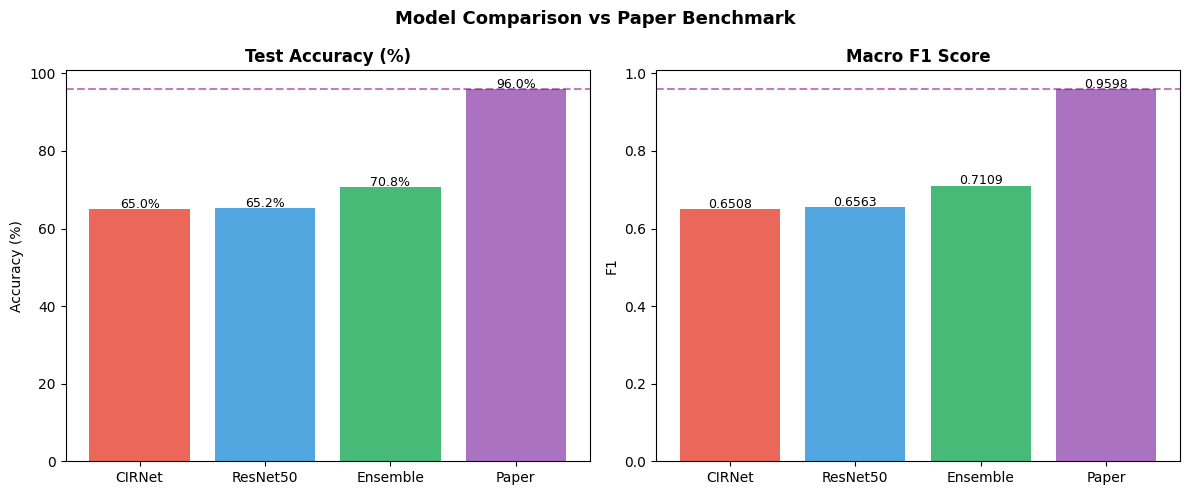

✅ All done — final_comparison.csv and final_comparison.png saved


In [ ]:
# Cell 10 — Ensemble + Final Comparison Table
# Ensemble: average CIRNet + ResNet50 probabilities
ens_probs = (cirnet_res['probs'] + resnet_res['probs']) / 2
ens_preds = np.argmax(ens_probs, axis=1)
true      = np.array(lbl_test)

ens_acc  = accuracy_score(true, ens_preds)*100
ens_f1   = f1_score(true, ens_preds, average='macro', zero_division=0)
ens_prec = precision_score(true, ens_preds, average='macro', zero_division=0)
ens_rec  = recall_score(true, ens_preds, average='macro', zero_division=0)

print('\n' + '='*65)
print('  FINAL MODEL COMPARISON')
print('='*65)
rows = [
    {'Model':'CIRNet (InceptionResNetV2)',
     'Accuracy':f"{cirnet_res['acc']:.2f}%",
     'Precision':f"{cirnet_res['prec']:.4f}",
     'Recall':f"{cirnet_res['rec']:.4f}",
     'F1':f"{cirnet_res['f1']:.4f}"},
    {'Model':'ResNet50',
     'Accuracy':f"{resnet_res['acc']:.2f}%",
     'Precision':f"{resnet_res['prec']:.4f}",
     'Recall':f"{resnet_res['rec']:.4f}",
     'F1':f"{resnet_res['f1']:.4f}"},
    {'Model':'Ensemble (CIRNet+ResNet50)',
     'Accuracy':f'{ens_acc:.2f}%',
     'Precision':f'{ens_prec:.4f}',
     'Recall':f'{ens_rec:.4f}',
     'F1':f'{ens_f1:.4f}'},
    {'Model':'Paper (CIR-Net+CDA)',
     'Accuracy':'95.98%',
     'Precision':'0.9600',
     'Recall':'0.9600',
     'F1':'0.9600'},
]
df_cmp = pd.DataFrame(rows)
print(df_cmp.to_string(index=False))
print('='*65)
df_cmp.to_csv(f'{OUTPUT_DIR}/final_comparison.csv', index=False)

# Bar chart
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
names = ['CIRNet','ResNet50','Ensemble','Paper']
accs  = [cirnet_res['acc'],resnet_res['acc'],ens_acc,95.98]
f1s   = [cirnet_res['f1'],resnet_res['f1'],ens_f1,0.9598]
colors= ['#E74C3C','#3498DB','#27AE60','#9B59B6']

ax1.bar(names,accs,color=colors,alpha=0.85)
ax1.axhline(95.98,color='purple',linestyle='--',alpha=0.5)
ax1.set_title('Test Accuracy (%)',fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
for i,(n,v) in enumerate(zip(names,accs)):
    ax1.text(i,v+0.3,f'{v:.1f}%',ha='center',fontsize=9)

ax2.bar(names,f1s,color=colors,alpha=0.85)
ax2.axhline(0.9598,color='purple',linestyle='--',alpha=0.5)
ax2.set_title('Macro F1 Score',fontweight='bold')
ax2.set_ylabel('F1')
for i,(n,v) in enumerate(zip(names,f1s)):
    ax2.text(i,v+0.003,f'{v:.4f}',ha='center',fontsize=9)

plt.suptitle('Model Comparison vs Paper Benchmark',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/final_comparison.png',dpi=150,bbox_inches='tight')
plt.show()
print('✅ All done — final_comparison.csv and final_comparison.png saved')


In [ ]:
# Cell 11 — Save to Google Drive
from google.colab import drive
import shutil

drive.mount('/content/drive', force_remount=False)
os.makedirs(SAVE_DIR, exist_ok=True)

files_to_save = [
    'CIRNet_best.keras', 'ResNet50_best.keras',
    'CIRNet_test_probs.npy', 'ResNet50_test_probs.npy',
    'lbl_test.npy',
    'CIRNet_results.csv', 'ResNet50_results.csv',
    'final_comparison.csv', 'final_comparison.png',
    'CIRNet_curves.png', 'ResNet50_curves.png',
    'CIRNet_confusion.png', 'ResNet50_confusion.png',
]
for f in files_to_save:
    src = f'{OUTPUT_DIR}/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'{SAVE_DIR}/{f}')
        print(f'✅ Saved: {f}')
    else:
        print(f'⚠️ Not found: {f}')
print(f'\n✅ All files saved to Drive: {SAVE_DIR}')


Mounted at /content/drive
✅ Saved: CIRNet_best.keras
✅ Saved: ResNet50_best.keras
✅ Saved: CIRNet_test_probs.npy
✅ Saved: ResNet50_test_probs.npy
✅ Saved: lbl_test.npy
✅ Saved: CIRNet_results.csv
✅ Saved: ResNet50_results.csv
✅ Saved: final_comparison.csv
✅ Saved: final_comparison.png
✅ Saved: CIRNet_curves.png
✅ Saved: ResNet50_curves.png
✅ Saved: CIRNet_confusion.png
✅ Saved: ResNet50_confusion.png

✅ All files saved to Drive: /content/drive/MyDrive/chromosome_models


In [1]:
import os

print("Current Directory:")
print(os.getcwd())

print("\nFiles:")
for f in os.listdir():
    print(f)

Current Directory:
/content

Files:
.config
sample_data


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os

MODEL_DIR = "/content/drive/MyDrive/Chromosome_Project"   # Change if needed

for root, dirs, files in os.walk(MODEL_DIR):
    for file in files:
        print(os.path.join(root, file))

In [6]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".keras"):
            print(os.path.join(root, file))

/content/drive/MyDrive/eurosat_model.keras
/content/drive/MyDrive/chromosome_models/CIRNet_best.keras
/content/drive/MyDrive/chromosome_models/ResNet50_best.keras


In [7]:
import tensorflow as tf
from tensorflow.keras.models import load_model

MODEL_DIR = "/content/drive/MyDrive/chromosome_models"

cirnet = load_model(f"{MODEL_DIR}/CIRNet_best.keras", compile=False)
resnet = load_model(f"{MODEL_DIR}/ResNet50_best.keras", compile=False)

print("✓ CIRNet Loaded")
print("✓ ResNet50 Loaded")

✓ CIRNet Loaded
✓ ResNet50 Loaded


In [8]:
print("CIRNet Input Shape :", cirnet.input_shape)
print("ResNet Input Shape :", resnet.input_shape)

print("CIRNet Output Shape :", cirnet.output_shape)
print("ResNet Output Shape :", resnet.output_shape)

CIRNet Input Shape : (None, 224, 224, 3)
ResNet Input Shape : (None, 224, 224, 3)
CIRNet Output Shape : (None, 24)
ResNet Output Shape : (None, 24)


In [9]:
import numpy as np

dummy = np.random.rand(1,224,224,3).astype(np.float32)

pred = cirnet.predict(dummy, verbose=0)

print(pred.shape)

(1, 24)


In [15]:
import os

DATASET = "/content/bioimlab"   # Change if your dataset is elsewhere

class_names = sorted(os.listdir(DATASET))

print(class_names)

['Class_1', 'Class_10', 'Class_11', 'Class_12', 'Class_13', 'Class_14', 'Class_15', 'Class_16', 'Class_17', 'Class_18', 'Class_19', 'Class_2', 'Class_20', 'Class_21', 'Class_22', 'Class_3', 'Class_4', 'Class_5', 'Class_6', 'Class_7', 'Class_8', 'Class_9', 'Class_X', 'Class_Y']


In [16]:
import json

class_names = [
    'Class_1',
    'Class_10',
    'Class_11',
    'Class_12',
    'Class_13',
    'Class_14',
    'Class_15',
    'Class_16',
    'Class_17',
    'Class_18',
    'Class_19',
    'Class_2',
    'Class_20',
    'Class_21',
    'Class_22',
    'Class_3',
    'Class_4',
    'Class_5',
    'Class_6',
    'Class_7',
    'Class_8',
    'Class_9',
    'Class_X',
    'Class_Y'
]

label_map = {i: class_names[i] for i in range(len(class_names))}

with open("/content/drive/MyDrive/chromosome_models/label_map.json", "w") as f:
    json.dump(label_map, f, indent=4)

print("✓ label_map.json saved")

✓ label_map.json saved


In [20]:
#prediction function
import cv2
import numpy as np
import tensorflow as tf
import json
import os

with open("/content/drive/MyDrive/chromosome_models/label_map.json") as f:
    label_map = json.load(f)

def predict_chromosome(image_path, model):

    if not os.path.exists(image_path):
        print(f"❌ Image not found: {image_path}")
        return None

    img = cv2.imread(image_path)

    if img is None:
        print("❌ OpenCV could not read the image.")
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224,224))
    img = img.astype(np.float32)

    img = tf.keras.applications.resnet50.preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0]

    idx = np.argmax(pred)
    confidence = pred[idx]

    print(f"Prediction : {label_map[str(int(idx))]}")
    print(f"Confidence : {confidence*100:.2f}%")

    return label_map[str(int(idx))], confidence

In [21]:
predict_chromosome("/content/test.png", cirnet)

❌ Image not found: /content/test.png


# New section
  XML - Yolo dataset detection

In [22]:
#Install YOLO
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.3 MB/s eta 0:00:00


In [23]:
#Imports
import os
import shutil
import random
import xml.etree.ElementTree as ET

from tqdm import tqdm

In [24]:
#Dataset paths
ROOT = "/content/Data"

IMG_DIR = os.path.join(ROOT,
                       "24_chromosomes_object",
                       "JPEG")

XML_DIR = os.path.join(ROOT,
                       "24_chromosomes_object",
                       "annotations")

YOLO_DIR = "/content/yolo_dataset"

os.makedirs(YOLO_DIR, exist_ok=True)

In [25]:
#Label mapping
CLASS_MAP = {
    "A1":0,
    "A2":1,
    "A3":2,
    "B4":3,
    "B5":4,
    "C6":5,
    "C7":6,
    "C8":7,
    "C9":8,
    "C10":9,
    "C11":10,
    "C12":11,
    "D13":12,
    "D14":13,
    "D15":14,
    "E16":15,
    "E17":16,
    "E18":17,
    "F19":18,
    "F20":19,
    "G21":20,
    "G22":21,
    "X":22,
    "Y":23
}

In [29]:
import os

ROOT="/content/drive/MyDrive/Chromo_dataset/Data"

print(os.listdir(ROOT))

['train.txt', 'test.txt', 'number_abnormalities.csv', 'Readme.txt', 'structural_abnormalities.csv', 'normal.csv', 'diff_image.txt', '24_chromosomes_object', 'weight', 'single_chromosomes_object']


In [41]:
#read train/test IDs
import os
import random

ROOT = "/content/drive/MyDrive/Chromo_dataset/Data"

TRAIN_FILE = os.path.join(ROOT, "train.txt")
TEST_FILE  = os.path.join(ROOT, "test.txt")

with open(TRAIN_FILE, "r") as f:
    train_ids = [x.strip() for x in f.readlines() if x.strip()]

with open(TEST_FILE, "r") as f:
    test_ids = [x.strip() for x in f.readlines() if x.strip()]

random.seed(42)
random.shuffle(train_ids)

split = int(0.9 * len(train_ids))

val_ids = train_ids[split:]
train_ids = train_ids[:split]

print("Train:", len(train_ids))
print("Val:", len(val_ids))
print("Test:", len(test_ids))

Train: 3375
Val: 375
Test: 1250


In [42]:
ROOT = "/content/drive/MyDrive/Chromo_dataset/Data"

IMG_DIR = os.path.join(
    ROOT,
    "24_chromosomes_object",
    "JEPG"          # <-- use JEPG
)

XML_DIR = os.path.join(
    ROOT,
    "24_chromosomes_object",
    "annotations"
)

YOLO_DIR = "/content/yolo_dataset"

print(os.path.exists(IMG_DIR))
print(os.path.exists(XML_DIR))

True
True


In [43]:
#Create YOLO folders
folders = [
    "images/train",
    "images/val",
    "images/test",
    "labels/train",
    "labels/val",
    "labels/test"
]

for folder in folders:
    os.makedirs(os.path.join(YOLO_DIR, folder), exist_ok=True)

print("Folders Created")

Folders Created


In [57]:
#XML - YOLO conversion
import shutil
import xml.etree.ElementTree as ET

def convert(xml_file, txt_file):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    w = float(root.find("size/width").text)
    h = float(root.find("size/height").text)

    lines = []

    for obj in root.findall("object"):

        cls = obj.find("name").text

        if cls not in CLASS_MAP:
            continue

        cls_id = CLASS_MAP[cls]

        box = obj.find("bndbox")

        xmin = float(box.find("xmin").text)
        xmax = float(box.find("xmax").text)

        ymin = float(box.find("ymin").text)
        ymax = float(box.find("ymax").text)

        xc = (xmin + xmax) / 2 / w
        yc = (ymin + ymax) / 2 / h

        bw = (xmax - xmin) / w
        bh = (ymax - ymin) / h

        lines.append(f"{cls_id} {xc} {yc} {bw} {bh}")

    with open(txt_file, "w") as f:
        f.write("\n".join(lines))

In [59]:
from tqdm import tqdm
import shutil
import os

def process(ids, split):

    copied = 0
    missing = 0

    for img_id in tqdm(ids, desc=split):

        img = os.path.join(IMG_DIR, img_id + ".jpg")
        xml = os.path.join(XML_DIR, img_id + ".xml")

        if not os.path.exists(img):
            missing += 1
            continue

        if not os.path.exists(xml):
            missing += 1
            continue

        dst_img = os.path.join(YOLO_DIR, "images", split, img_id + ".jpg")
        dst_lbl = os.path.join(YOLO_DIR, "labels", split, img_id + ".txt")

        shutil.copy(img, dst_img)      # Faster than copy2
        convert(xml, dst_lbl)

        copied += 1

    print(f"{split}: copied={copied}, missing={missing}")

In [61]:
process(train_ids, "train")
process(val_ids, "val")
process(test_ids, "test")

train: 100%|██████████| 3375/3375 [16:23<00:00,  3.43it/s]


train: copied=3370, missing=5


val: 100%|██████████| 375/375 [04:52<00:00,  1.28it/s]


val: copied=374, missing=1


test: 100%|██████████| 1250/1250 [16:12<00:00,  1.29it/s]

test: copied=1250, missing=0


In [62]:
#Create dataset.yaml
yaml_text = f"""
path: {YOLO_DIR}

train: images/train
val: images/val
test: images/test

names:
  0: A1
  1: A2
  2: A3
  3: B4
  4: B5
  5: C6
  6: C7
  7: C8
  8: C9
  9: C10
  10: C11
  11: C12
  12: D13
  13: D14
  14: D15
  15: E16
  16: E17
  17: E18
  18: F19
  19: F20
  20: G21
  21: G22
  22: X
  23: Y
"""

with open(os.path.join(YOLO_DIR, "dataset.yaml"), "w") as f:
    f.write(yaml_text)

print("dataset.yaml created")

dataset.yaml created


# New section 3
#Train YOLOV8

In [63]:
#verify dataset
import os

print(len(os.listdir("/content/yolo_dataset/images/train")))
print(len(os.listdir("/content/yolo_dataset/labels/train")))

print(len(os.listdir("/content/yolo_dataset/images/val")))
print(len(os.listdir("/content/yolo_dataset/labels/val")))

print(len(os.listdir("/content/yolo_dataset/images/test")))
print(len(os.listdir("/content/yolo_dataset/labels/test")))

3370
3370
374
374
1250
1250


In [64]:
!pip install ultralytics -q

In [65]:
#import and load
from ultralytics import YOLO
model = YOLO("yolov8n.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [66]:
#Train
results = model.train(
    data="/content/yolo_dataset/dataset.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,
    patience=20,
    optimizer="Adam",
    lr0=1e-3,
    project="/content",
    name="ChromosomeYOLO"
)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ChromosomeYOLO, nbs=64, 

KeyboardInterrupt: 

In [72]:
!find /content -name "*.pt"

/content/yolov8n.pt
/content/drive/MyDrive/Chromo_dataset/Data/weight/best-24_chromosomes.pt
/content/drive/MyDrive/Chromo_dataset/Data/weight/best_single_chromosomes.pt
/content/ChromosomeYOLO/weights/last.pt
/content/ChromosomeYOLO/weights/best.pt
/content/yolo26n.pt


In [73]:
import shutil
import os

SAVE_DIR = "/content/drive/MyDrive/chromosome_models"
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy(
    "/content/ChromosomeYOLO/weights/best.pt",
    SAVE_DIR + "/YOLO_best.pt"
)

shutil.copy(
    "/content/ChromosomeYOLO/weights/last.pt",
    SAVE_DIR + "/YOLO_last.pt"
)

print("YOLO models saved successfully!")

YOLO models saved successfully!


In [74]:
import os

print(os.path.exists("/content/drive/MyDrive/chromosome_models/YOLO_best.pt"))
print(os.path.exists("/content/drive/MyDrive/chromosome_models/YOLO_last.pt"))

True
True


In [75]:
#Evaluate
best_model = YOLO("/content/ChromosomeYOLO/weights/best.pt")

metrics = best_model.val()

print(metrics)

Ultralytics 8.4.107 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,010,328 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2608.2±719.4 MB/s, size: 109.6 KB)
val: Scanning /content/yolo_dataset/labels/val.cache... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 56.0Mit/s 0.0s
val: /content/yolo_dataset/images/val/1056174.jpg: corrupt JPEG restored and saved
val: /content/yolo_dataset/images/val/1056372.jpg: corrupt JPEG restored and saved
val: /content/yolo_dataset/images/val/1056464.jpg: corrupt JPEG restored and saved
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 2.4it/s 10.1s
                   all        374      17204      0.963      0.942      0.984      0.849
                    A1        374        748      0.978      0.964       0.99      0.892
                    A2        374        748      0.978      

In [76]:
#Test on 1 image
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/chromosome_models/YOLO_best.pt")

results = model.predict(
    source="/content/drive/MyDrive/Chromo_dataset/Data/24_chromosomes_object/JEPG/103064.jpg",
    conf=0.25,
    save=True
)


image 1/1 /content/drive/MyDrive/Chromo_dataset/Data/24_chromosomes_object/JEPG/103064.jpg: 640x608 2 A1s, 2 A2s, 2 A3s, 3 B4s, 2 B5s, 2 C6s, 2 C7s, 2 C8s, 2 C9s, 2 C10s, 2 C11s, 2 C12s, 2 D13s, 2 D14s, 2 D15s, 2 E16s, 2 E17s, 2 E18s, 2 F19s, 2 F20s, 2 G21s, 2 G22s, 1 X, 1 Y, 88.9ms
Speed: 11.1ms preprocess, 88.9ms inference, 2.5ms postprocess per image at shape (1, 3, 640, 608)
Results saved to /content/runs/detect/predict


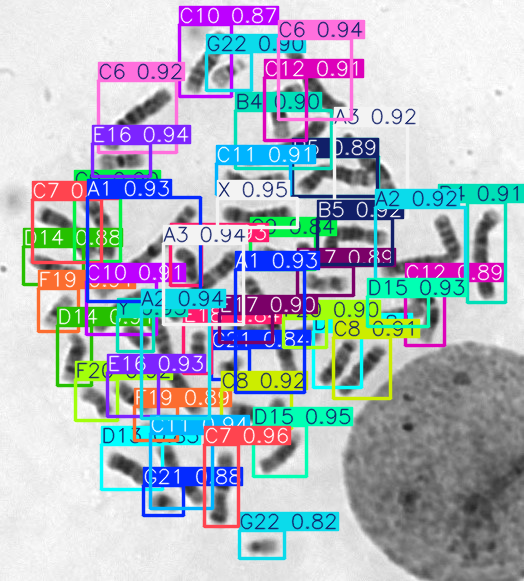

In [77]:
results[0].show()

In [ ]:
#Loading saved model
from google.colab import drive
drive.mount('/content/drive')
from ultralytics import YOLO
yolo = YOLO("/content/drive/MyDrive/chromosome_models/YOLO_best.pt")

# New section 3
#Final goal

In [89]:
#imports
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO
from tensorflow.keras.models import load_model

In [90]:
#Load models
# YOLO
yolo = YOLO("/content/drive/MyDrive/chromosome_models/YOLO_best.pt")

# CIRNet
cirnet = load_model("/content/drive/MyDrive/chromosome_models/CIRNet_best.keras")

# ResNet50
resnet = load_model("/content/drive/MyDrive/chromosome_models/ResNet50_best.keras")

print("All models loaded successfully.")

All models loaded successfully.


In [91]:
#Class names
class_names = [
    "1","2","3","4","5","6","7","8","9","10",
    "11","12","13","14","15","16","17","18","19",
    "20","21","22","X","Y"
]

print(class_names)

['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', 'X', 'Y']


(np.float64(-0.5), np.float64(523.5), np.float64(580.5), np.float64(-0.5))

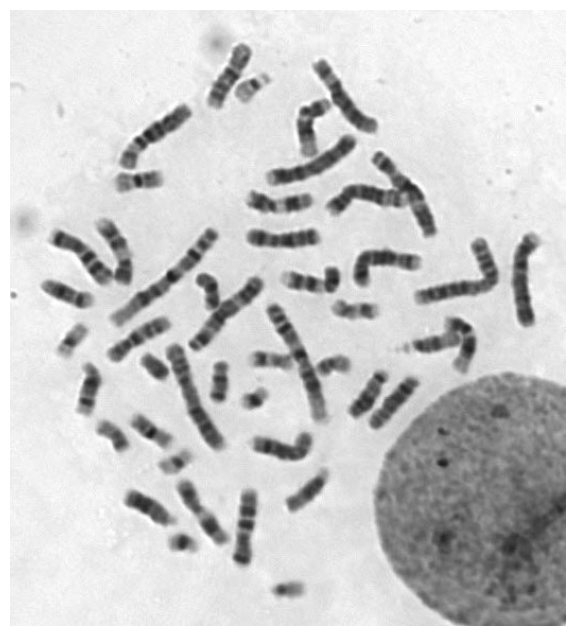

In [92]:
#select one test image
IMAGE_PATH="/content/drive/MyDrive/Chromo_dataset/Data/24_chromosomes_object/JEPG/103064.jpg"

image=cv2.imread(IMAGE_PATH)
image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")

In [93]:
# Yolo Detect chromosomes
results=yolo.predict(
    IMAGE_PATH,
    conf=0.25,
    verbose=False
)

boxes=results[0].boxes

print("Detected Chromosomes :",len(boxes))

Detected Chromosomes : 47


(np.float64(-0.5), np.float64(523.5), np.float64(580.5), np.float64(-0.5))

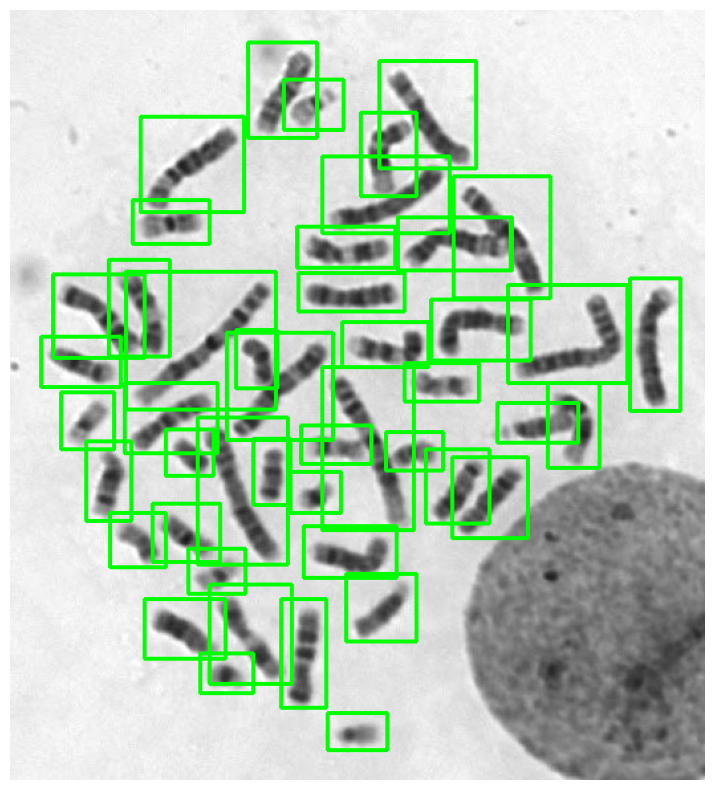

In [94]:
#Draw bownding boxes
img=image.copy()

for box in boxes:

    x1,y1,x2,y2=box.xyxy[0].cpu().numpy().astype(int)

    cv2.rectangle(
        img,
        (x1,y1),
        (x2,y2),
        (0,255,0),
        2
    )

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")

In [95]:
#crop every chromosome
chromosomes=[]

for box in boxes:

    x1,y1,x2,y2=box.xyxy[0].cpu().numpy().astype(int)

    crop=image[y1:y2,x1:x2]

    chromosomes.append(crop)

print("Total Cropped :",len(chromosomes))

Total Cropped : 47


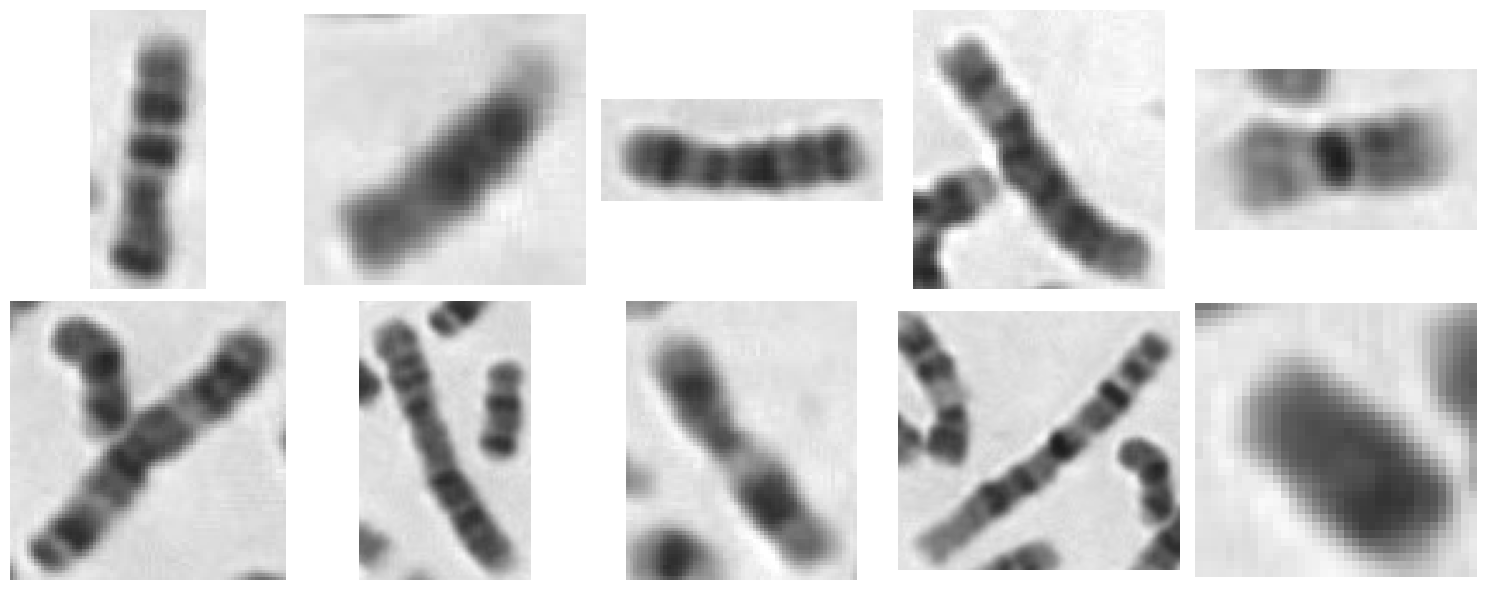

In [96]:
#Display first 10 crops
plt.figure(figsize=(15,6))

for i in range(min(10,len(chromosomes))):

    plt.subplot(2,5,i+1)
    plt.imshow(chromosomes[i])
    plt.axis("off")

plt.tight_layout()

In [97]:
#Resize for classifier
classifier_input=[]

for crop in chromosomes:

    img=cv2.resize(crop,(224,224))
    img=img.astype(np.float32)/255.0

    classifier_input.append(img)

classifier_input=np.array(classifier_input)

print(classifier_input.shape)

(47, 224, 224, 3)


# New section 3 - part2

In [98]:
#Read text.txt
import os

ROOT = "/content/drive/MyDrive/Chromo_dataset/Data"

with open(os.path.join(ROOT,"test.txt")) as f:
    test_ids = [x.strip() for x in f.readlines() if x.strip()]

print("Total Test Images :",len(test_ids))
print(test_ids[:5])

Total Test Images : 1250
['103191', '103192', '103193', '103201', '103202']


In [99]:
#Dataset paths
IMAGE_FOLDER = os.path.join(
    ROOT,
    "24_chromosomes_object",
    "JEPG"
)

XML_FOLDER = os.path.join(
    ROOT,
    "24_chromosomes_object",
    "annotations"
)

In [100]:
#XML reader
import xml.etree.ElementTree as ET

def read_xml(xml_path):

    tree = ET.parse(xml_path)
    root = tree.getroot()

    gt = []

    for obj in root.findall("object"):

        label = obj.find("name").text

        box = obj.find("bndbox")

        xmin = int(box.find("xmin").text)
        ymin = int(box.find("ymin").text)
        xmax = int(box.find("xmax").text)
        ymax = int(box.find("ymax").text)

        gt.append({
            "label":label,
            "bbox":[xmin,ymin,xmax,ymax]
        })

    return gt

In [101]:
#Text xml reader
sample = test_ids[0]

xml = os.path.join(XML_FOLDER,sample+".xml")

gt = read_xml(xml)

print("Ground Truth Objects :",len(gt))
print(gt[:3])

Ground Truth Objects : 46
[{'label': 'A1', 'bbox': [247, 484, 341, 594]}, {'label': 'A1', 'bbox': [521, 656, 628, 779]}, {'label': 'A2', 'bbox': [406, 150, 531, 271]}]


In [103]:
#Test images
all_predictions = []
all_groundtruth = []

for idx,image_id in enumerate(test_ids):

    image_path = os.path.join(
        IMAGE_FOLDER,
        image_id+".jpg"
    )

    xml_path = os.path.join(
        XML_FOLDER,
        image_id+".xml"
    )

    if not os.path.exists(image_path):
        continue

    if not os.path.exists(xml_path):
        continue

    gt = read_xml(xml_path)

    results = yolo.predict(
        image_path,
        conf=0.25,
        verbose=False
    )

    boxes = results[0].boxes

    print(f"{idx+1}/{len(test_ids)}",
          image_id,
          "GT:",len(gt),
          "Detected:",len(boxes))



1/1250 103191 GT: 46 Detected: 50
2/1250 103192 GT: 46 Detected: 48
3/1250 103193 GT: 46 Detected: 50
4/1250 103201 GT: 46 Detected: 51
5/1250 103202 GT: 46 Detected: 46
6/1250 103203 GT: 46 Detected: 47
7/1250 103212 GT: 46 Detected: 49
8/1250 103213 GT: 46 Detected: 49
9/1250 103214 GT: 46 Detected: 49
10/1250 103215 GT: 46 Detected: 49
11/1250 1032291 GT: 45 Detected: 50
12/1250 1032292 GT: 46 Detected: 46
13/1250 1032293 GT: 46 Detected: 47
14/1250 1032302 GT: 46 Detected: 47
15/1250 1032303 GT: 46 Detected: 48
16/1250 103231 GT: 46 Detected: 48
17/1250 104011 GT: 46 Detected: 48
18/1250 104024 GT: 46 Detected: 49
19/1250 104032 GT: 46 Detected: 53
20/1250 104074 GT: 46 Detected: 51
21/1250 104081 GT: 46 Detected: 51
22/1250 104103 GT: 46 Detected: 54
23/1250 104133 GT: 46 Detected: 49
24/1250 104134 GT: 46 Detected: 50
25/1250 104143 GT: 46 Detected: 47
26/1250 104153 GT: 46 Detected: 53
27/1250 104162 GT: 46 Detected: 46
28/1250 104173 GT: 46 Detected: 49
29/1250 104183 GT: 46 De

In [104]:
#Progress Bar
from tqdm import tqdm

for image_id in tqdm(test_ids):

    image_path = os.path.join(
        IMAGE_FOLDER,
        image_id+".jpg"
    )

    xml_path = os.path.join(
        XML_FOLDER,
        image_id+".xml"
    )

    if not os.path.exists(image_path):
        continue

    if not os.path.exists(xml_path):
        continue

    gt = read_xml(xml_path)

    results = yolo.predict(
        image_path,
        conf=0.25,
        verbose=False
    )

    boxes = results[0].boxes

100%|██████████| 1250/1250 [00:36<00:00, 33.81it/s]


In [105]:
#Lable mapping
label_map = {
    "A1":"1","A2":"2","A3":"3",
    "B4":"4","B5":"5",
    "C6":"6","C7":"7","C8":"8","C9":"9","C10":"10","C11":"11","C12":"12",
    "D13":"13","D14":"14","D15":"15",
    "E16":"16","E17":"17","E18":"18",
    "F19":"19","F20":"20",
    "G21":"21","G22":"22",
    "X":"X",
    "Y":"Y"
}

In [106]:
#Class names
class_names = [
    "1","2","3","4","5","6","7","8","9","10",
    "11","12","13","14","15","16","17","18",
    "19","20","21","22","X","Y"
]

In [107]:
#Image preprocessing
def preprocess(img):

    img = cv2.resize(img,(224,224))

    img = img.astype(np.float32)/255.0

    img = np.expand_dims(img,0)

    return img

In [108]:
#Ensemble prediction
def classify_chromosome(crop):

    x = preprocess(crop)

    p1 = cirnet.predict(x,verbose=0)[0]

    p2 = resnet.predict(x,verbose=0)[0]

    probs = (0.5*p1)+(0.5*p2)

    idx = np.argmax(probs)

    label = class_names[idx]

    confidence = float(np.max(probs))

    return label,confidence

In [109]:
#Test on 1 crop
label,conf = classify_chromosome(chromosomes[0])

print(label)
print(conf)

22
0.4429534375667572


In [110]:
#Classifying all yOLO detections
predictions=[]

for crop in chromosomes:

    label,conf = classify_chromosome(crop)

    predictions.append({
        "label":label,
        "confidence":conf
    })

print("Predictions :",len(predictions))

Predictions : 47


In [111]:
#View predictions
for i,p in enumerate(predictions):

    print(
        i+1,
        p["label"],
        round(p["confidence"],3)
    )

1 22 0.443
2 22 0.444
3 4 0.492
4 22 0.444
5 22 0.445
6 22 0.447
7 4 0.483
8 22 0.443
9 22 0.441
10 22 0.455
11 22 0.443
12 22 0.445
13 22 0.449
14 22 0.444
15 22 0.445
16 4 0.489
17 22 0.446
18 22 0.443
19 22 0.445
20 2 0.457
21 4 0.47
22 22 0.442
23 22 0.441
24 22 0.458
25 22 0.444
26 4 0.449
27 22 0.458
28 22 0.443
29 22 0.475
30 22 0.443
31 22 0.447
32 22 0.483
33 22 0.445
34 22 0.482
35 22 0.444
36 22 0.445
37 22 0.451
38 22 0.445
39 22 0.466
40 22 0.443
41 22 0.442
42 22 0.444
43 22 0.443
44 22 0.521
45 22 0.443
46 22 0.461
47 22 0.444


In [113]:
from tqdm import tqdm
import os
import cv2
import numpy as np

all_predictions = []
all_groundtruth = []
all_pred_boxes = []
all_gt_boxes = []

for image_id in tqdm(test_ids):

    image_path = os.path.join(
        IMAGE_FOLDER,
        image_id + ".jpg"
    )

    xml_path = os.path.join(
        XML_FOLDER,
        image_id + ".xml"
    )

    if not os.path.exists(image_path):
        continue

    if not os.path.exists(xml_path):
        continue

    # ---------------------------
    # Read Ground Truth
    # ---------------------------

    gt = read_xml(xml_path)

    # ---------------------------
    # Read Image
    # ---------------------------

    image = cv2.imread(image_path)

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # ---------------------------
    # YOLO Detection
    # ---------------------------

    results = yolo.predict(
        image_path,
        conf=0.25,
        verbose=False
    )

    boxes = results[0].boxes

    if len(boxes) == 0:
        continue

    # ---------------------------
    # Crop all chromosomes
    # ---------------------------

    crops = []
    pred_boxes = []

    for box in boxes:

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)

        crop = image[y1:y2, x1:x2]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (224,224))
        crop = crop.astype(np.float32) / 255.0

        crops.append(crop)
        pred_boxes.append([x1,y1,x2,y2])

    if len(crops) == 0:
        continue

    crops = np.array(crops)

    # ---------------------------
    # CIRNet Prediction
    # ---------------------------

    cir_probs = cirnet.predict(
        crops,
        verbose=0
    )

    # ---------------------------
    # ResNet50 Prediction
    # ---------------------------

    res_probs = resnet.predict(
        crops,
        verbose=0
    )

    # ---------------------------
    # Ensemble
    # ---------------------------

    final_probs = (cir_probs + res_probs) / 2

    pred_labels = []

    for p in final_probs:

        idx = np.argmax(p)

        pred_labels.append(
            class_names[idx]
        )

    # ---------------------------
    # Ground Truth Labels
    # ---------------------------

    gt_labels = []

    gt_boxes = []

    for obj in gt:

        gt_labels.append(
            label_map[obj["label"]]
        )

        gt_boxes.append(
            obj["bbox"]
        )

    # ---------------------------
    # Save Results
    # ---------------------------

    all_predictions.append(pred_labels)

    all_groundtruth.append(gt_labels)

    all_pred_boxes.append(pred_boxes)

    all_gt_boxes.append(gt_boxes)

print("Finished Processing")
print("Images Processed :", len(all_predictions))

100%|██████████| 1250/1250 [18:23<00:00,  1.13it/s]

Finished Processing
Images Processed : 1250


In [114]:
#IoU function
def compute_iou(box1, box2):

    xA = max(box1[0], box2[0])
    yA = max(box1[1], box2[1])

    xB = min(box1[2], box2[2])
    yB = min(box1[3], box2[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    area1 = (box1[2]-box1[0])*(box1[3]-box1[1])
    area2 = (box2[2]-box2[0])*(box2[3]-box2[1])

    union = area1 + area2 - inter

    if union == 0:
        return 0

    return inter/union

In [115]:
#Match yolo to xml
def match_predictions(pred_boxes, gt_objects):

    matched = []

    used = set()

    for p in pred_boxes:

        best_iou = 0
        best_gt = None

        for i,g in enumerate(gt_objects):

            if i in used:
                continue

            iou = compute_iou(p["bbox"], g["bbox"])

            if iou > best_iou:
                best_iou = iou
                best_gt = i

        if best_gt is not None:

            used.add(best_gt)

            matched.append((p, gt_objects[best_gt]))

    return matched

In [116]:
#Store prediction bounding boxes
predictions=[]

for box in boxes:

    x1,y1,x2,y2 = box.xyxy[0].cpu().numpy().astype(int)

    crop = image[y1:y2,x1:x2]

    label,conf = classify_chromosome(crop)

    predictions.append({

        "label":label,

        "confidence":conf,

        "bbox":[x1,y1,x2,y2]

    })

In [117]:
#Match predictions
matched = match_predictions(
    predictions,
    gt
)

print(len(matched))

46


In [118]:
#Calculate accuracy
correct = 0
total = 0

for pred,gt_obj in matched:

    true_label = label_map[gt_obj["label"]]

    if pred["label"] == true_label:
        correct += 1

    total += 1

print("Correct :",correct)
print("Total :",total)
print("Accuracy :",correct/total)

Correct : 2
Total : 46
Accuracy : 0.043478260869565216


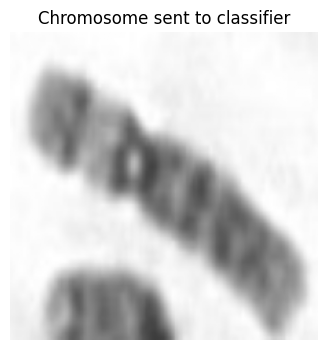

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.imshow(crop)
plt.title("Chromosome sent to classifier")
plt.axis("off")
plt.show()

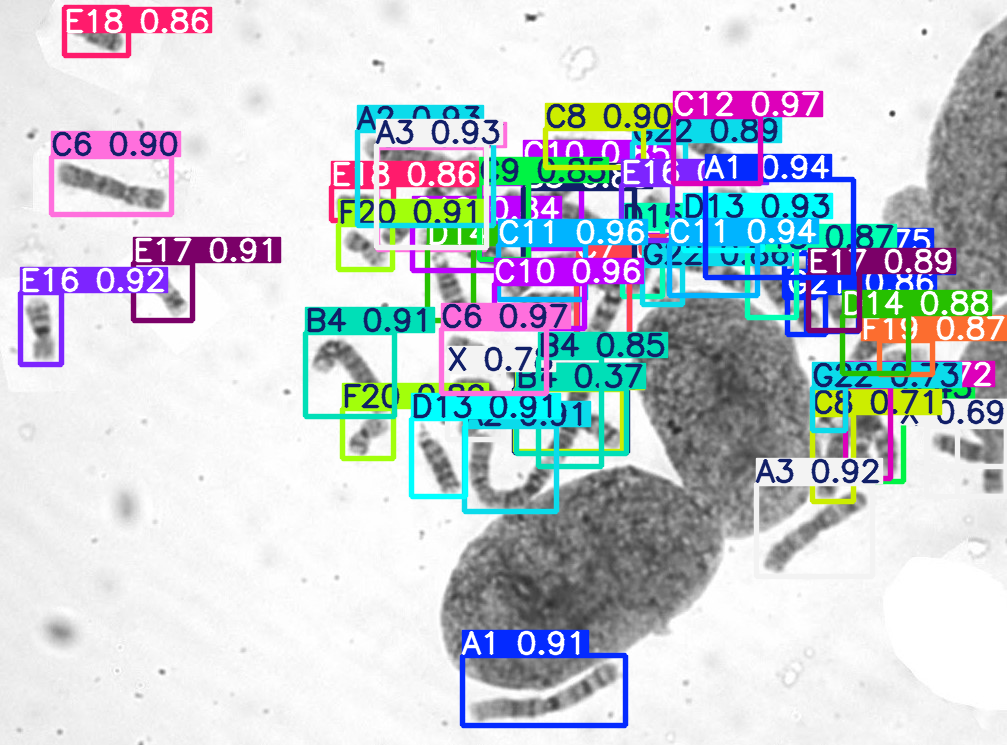

In [125]:
results = yolo.predict(
    image_path,
    conf=0.25,
    verbose=False
)

results[0].show()